# DVCS CFF fit results (observable training)

Plots of the recently-updated output CSVs from `CFF_NN_Fitter` (Jun 23):

| File | Content |
|---|---|
| `cff_learning_curve.csv` | epoch, train χ², val χ² |
| `obs_prediction.csv` | `xB,t,Q2,E,phi,obs_true,obs_pred,error` per point |
| `obs_model_eval.csv` | observable, mse, r_squared, chi2 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
lc    = pd.read_csv('../Partons_output/cff_learning_curve.csv')
obs   = pd.read_csv('../Partons_output/obs_prediction.csv')
evald = pd.read_csv('../Partons_output/obs_model_eval.csv')

In [3]:
import json

print("Model evaluation metrics")
print("-" * 55)
for _, row in evald.iterrows():
    print(f"{row['observable']:>26s}  MSE = {row['mse']:.6g}  "
          f"R² = {row['r_squared']:.6g}  χ² = {row['chi2']:.6g}")

# Best validation loss reached during training (tracked every epoch by train_nn(),
# exported by predict()). Fall back to the learning-curve minimum (logged every
# 2 epochs) for cff_model.json files that predate the best_val_chi2 field.
with open('../Partons_output/cff_model.json') as f:
    best_val = json.load(f).get('best_val_chi2')
if best_val is None:
    best_val = lc['val_loss'].min()
    print(f"\nBest val χ² = {best_val:.6g}  (min of learning curve; not in cff_model.json)")
else:
    print(f"\nBest val χ² = {best_val:.6g}")

Model evaluation metrics
-------------------------------------------------------
  DVCSAluMinusSin1PhiTorch  MSE = 0.000550638  R² = 0.519223  χ² = 8.194

Best val χ² = 5.12453


## Training and validation loss (χ²)

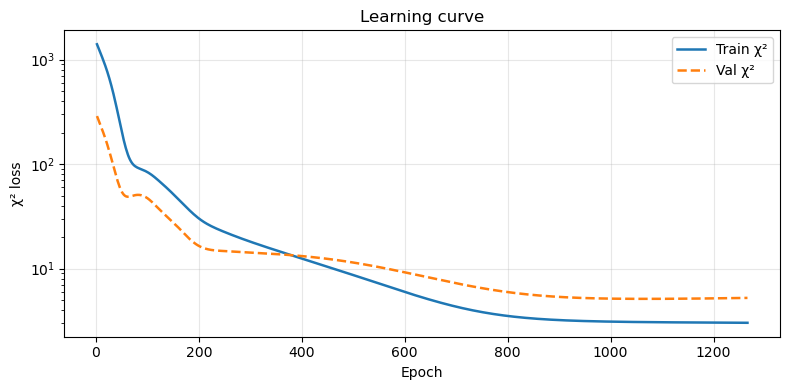

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lc['epoch'], lc['train_loss'], label='Train χ²', linewidth=1.8)
ax.plot(lc['epoch'], lc['val_loss'],   label='Val χ²',   linewidth=1.8, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('χ² loss')
ax.set_yscale('log')
ax.set_title('Learning curve')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Predicted vs measured observable ($A_{LU}^{\sin 1\phi}$)

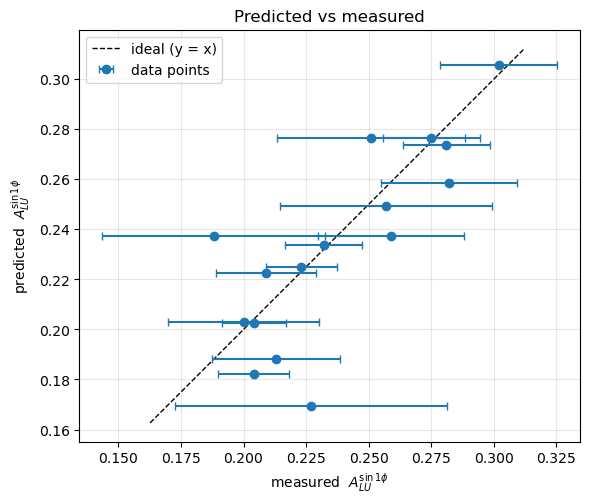

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.errorbar(obs['obs_true'], obs['obs_pred'], xerr=obs['error'], fmt='o',
            ms=6, capsize=3, zorder=3, label='data points')

lo = min(obs['obs_true'].min(), obs['obs_pred'].min())
hi = max(obs['obs_true'].max(), obs['obs_pred'].max())
pad = 0.05 * (hi - lo)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1, label='ideal (y = x)')

ax.set_xlabel(r'measured  $A_{LU}^{\sin 1\phi}$')
ax.set_ylabel(r'predicted  $A_{LU}^{\sin 1\phi}$')
ax.set_title('Predicted vs measured')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', 'box')
fig.tight_layout()
plt.show()

## Residuals: $y_\mathrm{true} - y_\mathrm{pred}$ vs row

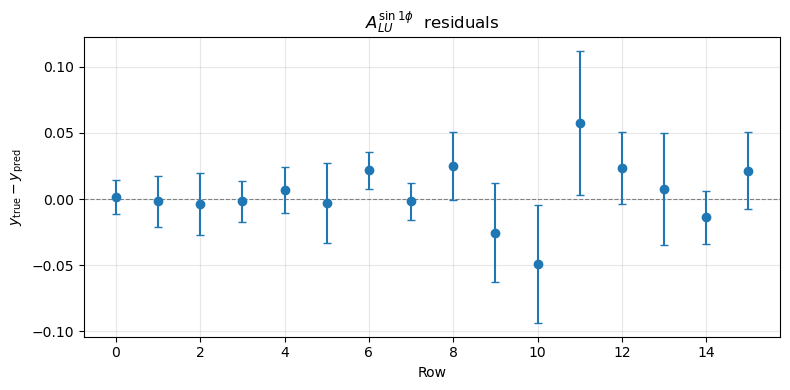

In [6]:
residuals = obs['obs_true'] - obs['obs_pred']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.errorbar(obs.index, residuals, yerr=obs['error'], fmt='o', ms=6, capsize=3, zorder=3)
ax.set_xlabel('Row')
ax.set_ylabel(r'$y_{\mathrm{true}} - y_{\mathrm{pred}}$')
ax.set_title(r'$A_{LU}^{\sin 1\phi}$  residuals')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Relative residuals: $(y_\mathrm{true} - y_\mathrm{pred}) / y_\mathrm{true}$ vs $y_\mathrm{true}$

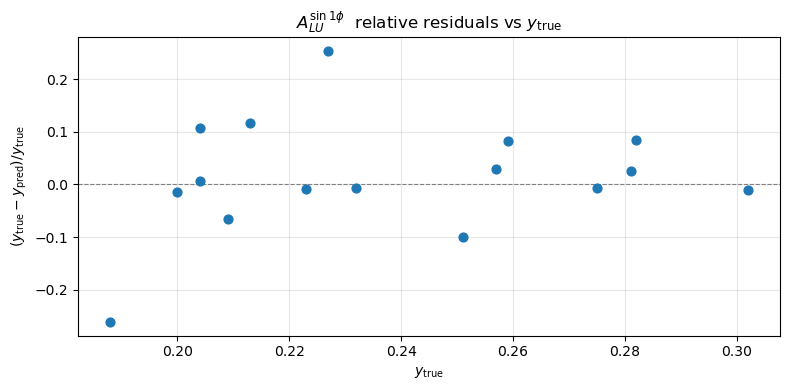

In [7]:
rel_residuals = (obs['obs_true'] - obs['obs_pred']) / obs['obs_true']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.scatter(obs['obs_true'], rel_residuals, s=40, zorder=3)
ax.set_xlabel(r'$y_{\mathrm{true}}$')
ax.set_ylabel(r'$(y_{\mathrm{true}} - y_{\mathrm{pred}}) / y_{\mathrm{true}}$')
ax.set_title(r'$A_{LU}^{\sin 1\phi}$  relative residuals vs $y_{\mathrm{true}}$')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Pull distribution: $(y_\mathrm{true} - y_\mathrm{pred}) / \sigma$

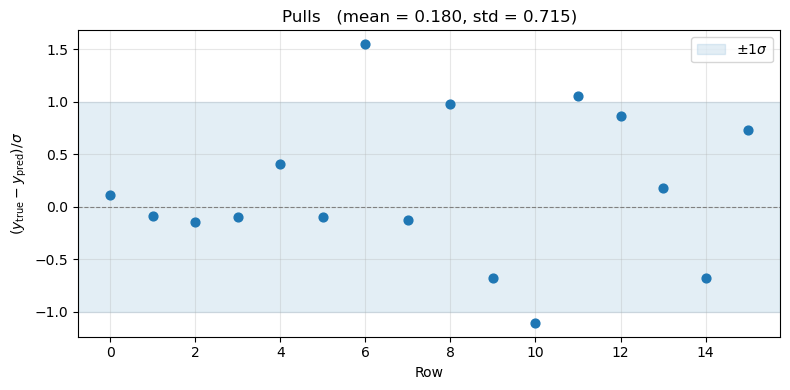

In [8]:
pulls = (obs['obs_true'] - obs['obs_pred']) / obs['error']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhspan(-1, 1, color='C0', alpha=0.12, label=r'$\pm 1\sigma$')
ax.scatter(obs.index, pulls, s=40, zorder=3)
ax.set_xlabel('Row')
ax.set_ylabel(r'$(y_{\mathrm{true}} - y_{\mathrm{pred}}) / \sigma$')
ax.set_title(f"Pulls   (mean = {pulls.mean():.3f}, std = {pulls.std():.3f})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## CFF scans from the trained NN

Reads `cff_model.json` (exported by `CFF_NN_Fitter::predict()`) and reproduces the NN
forward exactly (`DVCSCFFNNTorch::forwardNN()`: float32, same per-feature min-max scaling),
then scans the CFFs along one kinematic variable with the other two fixed.

In [9]:
import json

with open('../Partons_output/cff_model.json') as f:
    model = json.load(f)

W1 = np.array(model['fc1']['weight'], dtype=np.float32)   # [hidden, in]
b1 = np.array(model['fc1']['bias'],   dtype=np.float32)   # [hidden]
W2 = np.array(model['fc2']['weight'], dtype=np.float32)   # [out, hidden]
b2 = np.array(model['fc2']['bias'],   dtype=np.float32)   # [out]
labels = model['output_layer']                            # CFF name per output column
xmin = np.array(model['scaling']['x_min'], np.float32) if model['scaling']['x_min'] is not None else None
xmax = np.array(model['scaling']['x_max'], np.float32) if model['scaling']['x_max'] is not None else None

def cff_forward(X):
    """X: array [...,3] = (xB, t, Q2). Returns [...,n_outputs], columns = labels.
    Mirrors DVCSCFFNNTorch::forwardNN(): float32 + (x - xmin)/clamp(xmax - xmin, 1e-8)."""
    X = np.asarray(X, dtype=np.float32)
    if xmin is not None and xmax is not None:
        X = (X - xmin) / np.maximum(xmax - xmin, 1e-8).astype(np.float32)
    H = np.tanh(X @ W1.T + b1)
    return H @ W2.T + b2

def cff_scan(xB, t, Q2):
    """Broadcast scalar/array xB,t,Q2 -> [N,3], forward -> [N, n_outputs]."""
    xB, t, Q2 = np.broadcast_arrays(np.float32(xB), np.float32(t), np.float32(Q2))
    X = np.stack([xB.ravel(), t.ravel(), Q2.ravel()], axis=1)
    return cff_forward(X)

print('NN architecture:', model['arch'])
print('CFFs output by the NN:', labels)

NN architecture: {'in': 3, 'hidden': 6, 'out': 1, 'activation': 'tanh'}
CFFs output by the NN: ['ImH']


### CFFs vs $x_B$  (fixed $t=-0.2$ GeV$^2$, $Q^2=2$ GeV$^2$)

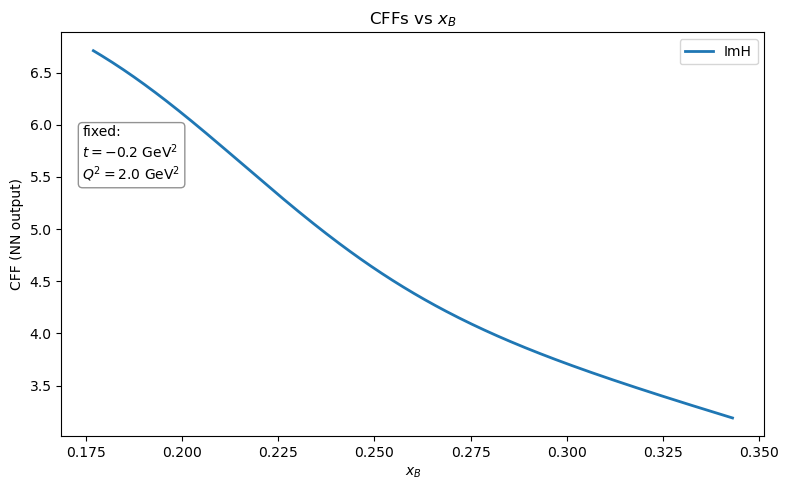

In [10]:
#xB = np.linspace(0.05, 0.30, 300)
xB = np.linspace(0.177, 0.343, 300)  #to match the fitted range
t_fix, Q2_fix = -0.2, 2.0
Y = cff_scan(xB, t_fix, Q2_fix)

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    ax.plot(xB, Y[:, k], lw=2, label=name)
ax.set_xlabel(r'$x_B$')
ax.set_ylabel('CFF (NN output)')
ax.set_title(r'CFFs vs $x_B$')
ax.text(0.03, 0.77, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB.png', dpi=150, bbox_inches='tight')
plt.show()

### CFFs vs $-t$  (fixed $x_B=0.2$, $Q^2=2.2$ GeV$^2$)

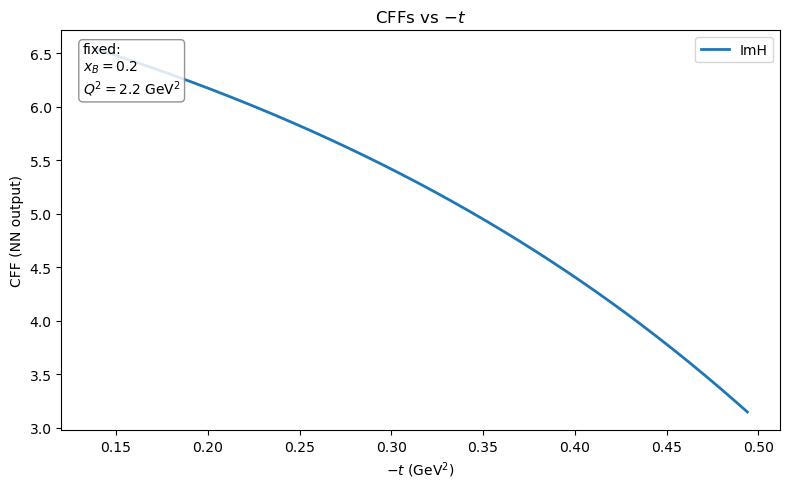

In [11]:
#mt = np.linspace(0.05, 0.50, 300)   # -t = |t|
mt = np.linspace(0.138, 0.494, 300)  # to match the fitted range
t  = -mt                            # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2
Y = cff_scan(xB_fix, t, Q2_fix)

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    ax.plot(mt, Y[:, k], lw=2, label=name)
ax.set_xlabel(r'$-t$ (GeV$^2$)')
ax.set_ylabel('CFF (NN output)')
ax.set_title(r'CFFs vs $-t$')
ax.text(0.03, 0.97, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt.png', dpi=150, bbox_inches='tight')
plt.show()